# Maritime Scene Clustering — ST-GAT + Moirai SSL (v2, RTX 3060)

Pipeline complet avec :
- Echantillonnage temporel reparti sur l'annee (6 periodes de 10 jours)
- Construction correcte des scenes 49D (ego 13D + env 9D + 3 voisins 27D)
- 5 voisins reels par navire dans le graphe ST-GAT
- Lecture des fichiers AIS_Status officiels (nav status, ship types, MMSI country)
- Traitement navire par navire avec voisinage spatial reel
- Lookups ocean/meteo via KDTree (rapide)

## 1. Imports et configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.spatial import cKDTree

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import geopandas as gpd
from shapely.geometry import Point
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---- paths ----
DATA_DIR = Path('Ais_status')
GEO_DIR  = Path('data/geo')
OUT_DIR  = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

# ---- GPU ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ---- parametres globaux ----
SEED        = 42
NROWS_AIS   = None       # None = tout charger ; 300_000 = test rapide
BATCH_SIZE  = 16         # batch physique RTX 3060 6GB
GRAD_ACCUM  = 4          # batch effectif = 64
NUM_WORKERS = 4
NUM_EPOCHS  = 30
LR          = 3e-4

# ---- parametres scenes ----
WINDOW_MIN    = 5        # fenetre ±2.5 min
CONTEXT_STEPS = 12       # 2 min a 10s
HORIZON_STEPS = 30       # 5 min a 10s
K_NEIGHBORS   = 5        # voisins dans le graphe
MAX_DIST_NM   = 5.0      # rayon max aretes
MASK_RATIO    = 0.5

# ---- parametres modele ----
N_FEATURES   = 16
EDGE_DIM     = 5
D_MODEL      = 128
GAT_HEADS    = 8
ENC_DIM      = 256

# ---- clustering ----
MAX_PER_CLASS = 2500
PCA_DIMS      = 30
HDBSCAN_MIN   = 50

# zone Brest
BREST_LON = (-5.5, -3.5)
BREST_LAT = (47.5, 49.0)
NM_TO_DEG = 1.0 / 60.0

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config OK.')

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cpu
Config OK.


In [2]:
from pathlib import Path

BASE = Path(r'C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM')

AIS_DATA_DIR    = BASE / 'AIS_DATA'
AIS_STATUS_DIR  = BASE / 'AIS_Status'
COAST_DIR       = BASE / 'European_Coastline'
FISH_CONSTR_DIR = BASE / 'Fishing_Constraints'
FISH_VESSELS_DIR= BASE / 'Fishing_Vessels'
OCEAN_DIR       = BASE / 'OCEAN_DATA'
PORTS_DIR       = BASE / 'Ports_of_Brittany'
WEATHER_DIR     = BASE / 'WEATHER_DATA'
OUT_DIR         = BASE / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

# verification rapide
for name, p in [
    ('AIS_DATA',    AIS_DATA_DIR),
    ('AIS_Status',  AIS_STATUS_DIR),
    ('Coastline',   COAST_DIR),
    ('Fishing C.',  FISH_CONSTR_DIR),
    ('Fishing V.',  FISH_VESSELS_DIR),
    ('Ocean',       OCEAN_DIR),
    ('Ports',       PORTS_DIR),
    ('Weather',     WEATHER_DIR),
]:
    status = 'OK' if p.exists() else 'MANQUANT'
    print(f'  {name:<15} {status}  ({p})')

  AIS_DATA        OK  (C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\AIS_DATA)
  AIS_Status      OK  (C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\AIS_Status)
  Coastline       OK  (C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\European_Coastline)
  Fishing C.      OK  (C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\Fishing_Constraints)
  Fishing V.      OK  (C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\Fishing_Vessels)
  Ocean           OK  (C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\OCEAN_DATA)
  Ports           OK  (C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\Ports_of_Brittany)
  Weather         OK  (C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\WEATHER_DATA)


## 2. Lecture des fichiers AIS_Status (tables de reference officielles)

In [3]:
# Navigational Status — separateur point-virgule, pas de header
nav_raw = pd.read_csv(
    AIS_STATUS_DIR / 'Navigational Status.csv',
    sep=';',
    header=None,
    names=['code', 'label'],
    encoding='utf-8',
)
nav_raw['code']  = nav_raw['code'].astype(int)
nav_raw['label'] = nav_raw['label'].str.strip()
print('Navigational Status :')
print(nav_raw.to_string(index=False))

# mapping code -> groupe comportemental
NAV_GROUP = {
    0:  0,   # under way using engine
    8:  0,   # under way sailing
    1:  1,   # at anchor
    5:  1,   # moored
    7:  2,   # engaged in fishing
    2:  3,   # not under command
    3:  3,   # restricted manoeuvrability
    4:  3,   # constrained by draught
    6:  3,   # aground
    14: 4,   # AIS-SART active
    15: 5,   # undefined / default
}
for code in range(16):
    if code not in NAV_GROUP:
        NAV_GROUP[code] = 5   # reserved -> unknown

NAV_GROUP_NAMES = {
    0: 'underway', 1: 'anchored', 2: 'fishing',
    3: 'restricted', 4: 'emergency', 5: 'unknown'
}
print('\nMapping NAV_GROUP OK.')

# Ship Types
ship_types_df = pd.read_csv(
    AIS_STATUS_DIR / 'Ship Types List.csv',
    sep=';',
    header=None,
    names=['code', 'label'],
    encoding='utf-8',
    on_bad_lines='skip',
)
print('\nShip Types (apercu) :')
print(ship_types_df.head(8).to_string(index=False))

def ship_cat(code):
    if pd.isna(code): return 7
    c = int(code)
    if 30 <= c <= 39: return 0
    if 70 <= c <= 79: return 1
    if 80 <= c <= 89: return 2
    if 60 <= c <= 69: return 3
    if 40 <= c <= 49: return 4
    if 50 <= c <= 59: return 5
    if 20 <= c <= 29: return 6
    if 90 <= c <= 99: return 7
    return 7

SHIP_CAT_NAMES = {
    0:'fishing', 1:'cargo', 2:'tanker', 3:'passenger',
    4:'fast', 5:'service', 6:'special', 7:'other'
}

# MMSI Country Codes
mmsi_country_df = pd.read_csv(
    AIS_STATUS_DIR / 'MMSI Country Codes.csv',
    sep=';',
    header=None,
    names=['mid', 'country'],
    encoding='utf-8',
    on_bad_lines='skip',
)
mmsi_country_df['mid'] = pd.to_numeric(mmsi_country_df['mid'], errors='coerce')
mmsi_country_df = mmsi_country_df.dropna(subset=['mid'])
mmsi_country_df['mid'] = mmsi_country_df['mid'].astype(int)
MID_COUNTRY = dict(zip(
    mmsi_country_df['mid'],
    mmsi_country_df['country'].fillna('').astype(str).str.strip()
))
def mmsi_to_mid(mmsi):
    try:
        return int(str(int(mmsi))[:3])
    except:
        return 0

print(f'\nPays references : {len(MID_COUNTRY)}')
print('Exemple :', list(MID_COUNTRY.items())[:5])

Navigational Status :
 code                                                                                                                                                                                                       label
    0                                                                                                                                                                                      under way using engine
    1                                                                                                                                                                                                   at anchor
    2                                                                                                                                                                                           not under command
    3                                                                                                                                     

## 3. Chargement AIS avec echantillonnage temporel reparti

In [4]:
# L'idee : charger toutes les donnees, puis selectionner 6 periodes de 10 jours
# bien reparties dans l'annee pour eviter le biais saisonnier.
# Periodes cibles : debut de chaque bimestre (jan, mars, mai, juil, sept, nov)

TARGET_MONTHS = [1, 3, 5, 7, 9, 11]   # 6 periodes
DAYS_PER_PERIOD = 10

print('Chargement AIS dynamique...')
ais_dyn = pd.read_csv(
    AIS_DATA_DIR / 'nari_dynamic.csv',
    nrows=NROWS_AIS,
    dtype={
        'sourcemmsi': 'int64',
        'navigationalstatus': 'float32',
        'rateofturn': 'float32',
        'speedoverground': 'float32',
        'courseoverground': 'float32',
        'trueheading': 'float32',   # float32 — evite TypeError Int16
        'lon': 'float64',
        'lat': 'float64',
        't': 'int64',
    }
).rename(columns={
    'sourcemmsi':       'mmsi',
    'navigationalstatus': 'nav_status',
    'rateofturn':       'rot',
    'speedoverground':  'speed_kt',
    'courseoverground': 'course_deg',
    'trueheading':      'heading_deg',
})
print(f'Brut : {len(ais_dyn):,} messages')

# conversion timestamp
ais_dyn['t'] = pd.to_datetime(ais_dyn['t'], unit='s', utc=True)

# filtrage zone Brest
ais_dyn = ais_dyn[
    ais_dyn['lon'].between(*BREST_LON) &
    ais_dyn['lat'].between(*BREST_LAT)
].reset_index(drop=True)
print(f'Apres filtre Brest : {len(ais_dyn):,} messages')

# ---- echantillonnage temporel reparti ----
ais_dyn['month'] = ais_dyn['t'].dt.month
ais_dyn['day']   = ais_dyn['t'].dt.day

periods_selected = []
for month in TARGET_MONTHS:
    month_data = ais_dyn[ais_dyn['month'] == month]
    if len(month_data) == 0:
        print(f'  Mois {month:02d} : aucune donnee')
        continue
    # prendre les DAYS_PER_PERIOD premiers jours du mois
    day_mask = month_data['day'] <= DAYS_PER_PERIOD
    period = month_data[day_mask]
    if len(period) == 0:
        # fallback : prendre les jours disponibles
        period = month_data
    periods_selected.append(period)
    print(f'  Mois {month:02d} : {len(period):,} messages ({period["mmsi"].nunique()} navires)')

ais = pd.concat(periods_selected, ignore_index=True)
print(f'Total apres echantillonnage reparti : {len(ais):,} messages')
print(f'Periodes : {ais["month"].unique()}')

# correction heading invalide
ais['heading_deg'] = (
    ais['heading_deg']
    .fillna(ais['course_deg'])
    .where(ais['heading_deg'].between(0, 359), other=ais['course_deg'].values)
    .astype('float32')
)

ais = ais.sort_values(['mmsi', 't']).reset_index(drop=True)
print(f'Navires uniques : {ais["mmsi"].nunique():,}')

Chargement AIS dynamique...
Brut : 19,035,630 messages
Apres filtre Brest : 18,665,867 messages
  Mois 01 : 798,467 messages (362 navires)
  Mois 03 : 1,424,971 messages (416 navires)
  Mois 05 : aucune donnee
  Mois 07 : aucune donnee
  Mois 09 : 6,913 messages (63 navires)
  Mois 11 : 1,010,999 messages (557 navires)
Total apres echantillonnage reparti : 3,241,350 messages
Periodes : [ 1  3  9 11]
Navires uniques : 944


In [5]:
# ---- fusion statique ----
print('Chargement AIS statique...')
ais_sta = pd.read_csv(
    AIS_DATA_DIR / 'nari_static.csv',
    usecols=['sourcemmsi', 'shiptype'],
    dtype={'sourcemmsi': 'int64', 'shiptype': 'float32'},
).rename(columns={'sourcemmsi': 'mmsi'})
ais_sta = ais_sta.drop_duplicates('mmsi')
ais_sta['ship_cat'] = ais_sta['shiptype'].apply(ship_cat).astype('int8')

# registre peche EU (EuropeanVesselRegister.csv)
try:
    evr = pd.read_csv(FISH_VESSELS_DIR / 'EuropeanVesselRegister.csv', nrows=3)
    print(f'Colonnes EVR : {evr.columns.tolist()}')
    # charger toutes les colonnes et chercher celle qui contient les MMSI
    evr_full = pd.read_csv(FISH_VESSELS_DIR / 'EuropeanVesselRegister.csv', dtype=str, low_memory=False)
    mmsi_col = next((c for c in evr_full.columns if 'mmsi' in c.lower()), None)
    if mmsi_col:
        fishing_mmsi = set(
            evr_full[mmsi_col].dropna()
            .str.strip()
            .loc[lambda s: s.str.match(r'^\d+$')]
            .astype(int)
        )
        print(f'Peche EU : {len(fishing_mmsi):,} MMSI (colonne: {mmsi_col})')
    else:
        print('Colonne MMSI non trouvee dans EVR — is_eu_fishing=0')
        print('Colonnes disponibles :', evr_full.columns.tolist())
        fishing_mmsi = set()
except Exception as e:
    fishing_mmsi = set()
    print(f'Registre peche non charge : {e}')

ais_sta['is_eu_fishing'] = ais_sta['mmsi'].isin(fishing_mmsi).astype('int8')

# pays depuis MID
ais['nav_group']     = ais['nav_status'].fillna(15).map(NAV_GROUP).fillna(5).astype('int8')
ais = ais.merge(ais_sta[['mmsi', 'ship_cat', 'is_eu_fishing']], on='mmsi', how='left')
ais['ship_cat']      = ais['ship_cat'].fillna(7).astype('int8')
ais['is_eu_fishing'] = ais['is_eu_fishing'].fillna(0).astype('int8')
ais['mid']           = ais['mmsi'].apply(mmsi_to_mid)
ais['country']       = ais['mid'].map(MID_COUNTRY).fillna('unknown')

print(f'Dataset fusionne : {len(ais):,} messages')
print(ais[['mmsi', 'nav_group', 'ship_cat', 'is_eu_fishing', 'country']].head(3))

Chargement AIS statique...
Colonnes EVR : ['countrycode;cfr;eventcode;eventstartdate;eventenddate;licenseind;registrationnbr;extmarking;vesselname;portcode;portname;ircscode;ircs;vmscode;gearmaincode;gearseccode;loa;lbp;tonref;tongt;tonoth;tongts;powermain;poweraux;hullmaterial;comyear;commonth;comday;segment;expcountry;exptype;publicaidcode;decisiondate;decisionsegcode;constructionyear;constructionplace']
Registre peche non charge : Error tokenizing data. C error: Expected 1 fields in line 6, saw 3

Dataset fusionne : 3,241,350 messages
        mmsi  nav_group  ship_cat  is_eu_fishing  country
0  205309000          1         0              0  unknown
1  205309000          1         0              0  unknown
2  205309000          1         0              0  unknown


## 4. Donnees geospatiales et environnementales (KDTree)

In [6]:
# ---- cote europeenne ----
print('Chargement cote...')
coast = gpd.read_file(
    COAST_DIR / 'Europe Coastline (Polygone).shp'
).to_crs('EPSG:4326')
coast_union = coast.geometry.unary_union
print('Cote chargee.')

# ---- zones de peche ----
try:
    fishing_zones = gpd.read_file(
        FISH_CONSTR_DIR / 'fishing_interdiction.shp'
    ).to_crs('EPSG:4326')
    fishing_union = fishing_zones.geometry.unary_union
    HAS_FISHING = True
    print('Zones peche chargees.')
except Exception as e:
    fishing_union = None
    HAS_FISHING = False
    print(f'Zones peche absentes : {e}')

# ---- ports Bretagne ----
ports_gdf    = gpd.read_file(PORTS_DIR / 'port.shp').to_crs('EPSG:4326')
print(f'Ports charges : {len(ports_gdf)} | type geometrie : {ports_gdf.geometry.geom_type.unique()}')

# extraction centroide quelle que soit la geometrie (point, polygone, ligne)
ports_centroids = ports_gdf.geometry.centroid
ports_coords = np.column_stack([
    ports_centroids.x.values,
    ports_centroids.y.values,
])
ports_tree = cKDTree(ports_coords)
print(f'KDTree ports construit sur {len(ports_coords)} centroides.')

# ---- grille precalculee cote/port/peche ----
print('Precalcul grille geospatiale (2-3 min)...')
GRID_STEP = 0.05
grid_lons  = np.arange(BREST_LON[0], BREST_LON[1] + GRID_STEP, GRID_STEP)
grid_lats  = np.arange(BREST_LAT[0], BREST_LAT[1] + GRID_STEP, GRID_STEP)
glo, gla   = np.meshgrid(grid_lons, grid_lats)
glo_flat   = glo.flatten()
gla_flat   = gla.flatten()

grid_coast = np.array([Point(lo, la).distance(coast_union) / NM_TO_DEG
                       for lo, la in tqdm(zip(glo_flat, gla_flat), total=len(glo_flat),
                                          desc='dist coast')])

query_pts = np.column_stack([glo_flat, gla_flat])
port_dists_deg, _ = ports_tree.query(query_pts)
grid_port = port_dists_deg / NM_TO_DEG

if HAS_FISHING:
    grid_infz = np.array([int(Point(lo, la).within(fishing_union))
                          for lo, la in tqdm(zip(glo_flat, gla_flat), total=len(glo_flat),
                                             desc='fishing zone')], dtype='float32')
else:
    grid_infz = np.zeros(len(glo_flat), dtype='float32')

grid_tree = cKDTree(query_pts)
grid_data = np.column_stack([grid_coast, grid_port, grid_infz])
print(f'Grille : {len(glo_flat)} cellules precalculees.')

def lookup_geo(lon, lat):
    _, idx = grid_tree.query([lon, lat])
    return grid_data[idx]

Chargement cote...
Cote chargee.
Zones peche chargees.
Ports charges : 222 | type geometrie : <ArrowStringArray>
['MultiPoint']
Length: 1, dtype: str
KDTree ports construit sur 222 centroides.
Precalcul grille geospatiale (2-3 min)...


fishing zone: 100%|██████████| 1271/1271 [00:00<00:00, 49934.06it/s]

Grille : 1271 cellules precalculees.


In [7]:
# ---- meteo ----
print('Chargement meteo...')
stations = pd.read_csv(WEATHER_DIR / 'table_weatherStation.csv').rename(
    columns={'latitude': 'lat', 'longitude': 'lon'}
)
wind_dir_table = pd.read_csv(WEATHER_DIR / 'table_windDirection.csv').rename(
    columns={'DD_num': 'wind_dir_deg'}
)
obs = pd.read_csv(WEATHER_DIR / 'table_wheatherObservation.csv',
                  parse_dates=['local_time'])
obs = obs.merge(wind_dir_table[['id_windDirection', 'wind_dir_deg']],
                on='id_windDirection', how='left')
obs = obs.merge(stations[['id_station', 'lat', 'lon']],
                on='id_station', how='left')
obs['wind_kt']       = obs['Ff'].fillna(0) * 1.944
obs['wind_dir_sin']  = np.sin(np.deg2rad(obs['wind_dir_deg'].fillna(0)))
obs['wind_dir_cos']  = np.cos(np.deg2rad(obs['wind_dir_deg'].fillna(0)))
obs['visibility_km'] = obs['VV'].fillna(10.0)
obs['local_time']    = pd.to_datetime(obs['local_time'], utc=True, errors='coerce')
obs['hour'] = obs['local_time'].dt.floor('h')
obs = obs.dropna(subset=['lat', 'lon', 'hour'])

sta_coords  = np.column_stack([stations['lon'].values, stations['lat'].values])
sta_tree    = cKDTree(sta_coords)
obs_by_hour = obs.groupby('hour')
obs_hours   = set(obs_by_hour.groups.keys())

FALLBACK_WEATHER = {
    'wind_kt':      float(obs['wind_kt'].median()),
    'wind_dir_sin': 0.0,
    'wind_dir_cos': 1.0,
    'visibility_km': 10.0,
}

def get_weather(lon, lat, timestamp):
    hour = pd.Timestamp(timestamp).floor('h')
    if not hasattr(hour, 'tz') or hour.tz is None:
        hour = hour.tz_localize('UTC')

    if len(obs_hours) == 0:
        return FALLBACK_WEATHER

    if hour in obs_hours:
        obs_h = obs_by_hour.get_group(hour)
    else:
        hour_list = sorted(obs_hours)
        diffs = [abs((h - hour).total_seconds()) for h in hour_list]
        if len(diffs) == 0:
            return FALLBACK_WEATHER
        obs_h = obs_by_hour.get_group(hour_list[np.argmin(diffs)])

    _, idx = sta_tree.query([lon, lat])
    sta_id = stations.iloc[idx]['id_station']
    row = obs_h[obs_h['id_station'] == sta_id]
    if len(row) == 0:
        return FALLBACK_WEATHER
    r = row.iloc[0]
    return {
        'wind_kt':       float(r.get('wind_kt',       FALLBACK_WEATHER['wind_kt'])),
        'wind_dir_sin':  float(r.get('wind_dir_sin',  0.0)),
        'wind_dir_cos':  float(r.get('wind_dir_cos',  1.0)),
        'visibility_km': float(r.get('visibility_km', 10.0)),
    }
# ---- ocean (KDTree) ----
print('Chargement donnees ocean...')
ocean_files = sorted(OCEAN_DIR.glob('oc_*.csv'))
if ocean_files:
    ocean = pd.concat([pd.read_csv(f, usecols=['lat', 'lon', 'hs'])
                       for f in ocean_files], ignore_index=True)
    ocean = ocean.dropna()
    ocean_coords = np.column_stack([ocean['lon'].values, ocean['lat'].values])
    ocean_tree   = cKDTree(ocean_coords)
    ocean_hs     = ocean['hs'].values
    print(f'Ocean : {len(ocean):,} points, KDTree construit.')
    def get_wave(lon, lat):
        _, idx = ocean_tree.query([lon, lat])
        return float(ocean_hs[idx])
else:
    print('Ocean absent.')
    def get_wave(lon, lat): return 0.0

print('Donnees environnementales prets.')

Chargement meteo...
Chargement donnees ocean...
Ocean : 79,269,855 points, KDTree construit.
Donnees environnementales prets.


## 5. Fonctions de comportement et de geometrie

In [8]:
def classify_behavior(speed, turn_rate, nav_group, ship_cat_code, dist_coast_nm):
    """
    Classification comportement en 7 classes (0-6).
    L'ordre des conditions est important : le nav_group AIS prime sur la vitesse.
    """
    if nav_group == 1 or speed < 0.5:      return 0  # ancre/amarre
    if nav_group == 3:                      return 6  # restreint
    if nav_group == 2 or ship_cat_code == 0: return 5  # peche (statut AIS ou type navire)
    if speed < 3.0:
        # lent ET vire ET cote -> peche probable
        if ship_cat_code == 0 and dist_coast_nm < 20.0 and abs(turn_rate) > 0.5:
            return 5
        return 1  # derive
    if abs(turn_rate) > 3.0:               return 2  # manoeuvre
    if speed <= 8.0:                        return 3  # transit lent
    return 4                                          # transit


def haversine_nm(lon1, lat1, lon2, lat2):
    R = 3440.065
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return float(2 * R * np.arcsin(np.clip(np.sqrt(a), 0, 1)))


def bearing_deg(lon1, lat1, lon2, lat2):
    """Cap depuis (lon1,lat1) vers (lon2,lat2) en degres [0, 360)."""
    dlon = np.radians(lon2 - lon1)
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    x = np.sin(dlon) * np.cos(lat2r)
    y = np.cos(lat1r)*np.sin(lat2r) - np.sin(lat1r)*np.cos(lat2r)*np.cos(dlon)
    return float((np.degrees(np.arctan2(x, y)) + 360) % 360)


def compute_cpa_tcpa(lon1, lat1, sog1, cog1, lon2, lat2, sog2, cog2):
    """Closest Point of Approach (nm) et Time to CPA (min)."""
    K = 1.0 / 60.0  # kt -> nm/min
    vx1 = sog1 * np.sin(np.radians(cog1)) * K
    vy1 = sog1 * np.cos(np.radians(cog1)) * K
    vx2 = sog2 * np.sin(np.radians(cog2)) * K
    vy2 = sog2 * np.cos(np.radians(cog2)) * K
    lat_mid = (lat1 + lat2) / 2
    dx  = (lon2 - lon1) * 60 * np.cos(np.radians(lat_mid))
    dy  = (lat2 - lat1) * 60
    dvx, dvy = vx2 - vx1, vy2 - vy1
    dv2 = dvx**2 + dvy**2
    if dv2 < 1e-9:
        return haversine_nm(lon1, lat1, lon2, lat2), 999.0
    tcpa = max(0.0, -(dx*dvx + dy*dvy) / dv2)
    cpa  = np.sqrt((dx + dvx*tcpa)**2 + (dy + dvy*tcpa)**2)
    return float(cpa), float(tcpa)


def collision_risk(cpa_nm, tcpa_min):
    return float(np.exp(-cpa_nm / 0.5) * np.exp(-tcpa_min / 15.0))


def relative_speed(lon1, lat1, sog1, cog1, lon2, lat2, sog2, cog2):
    """Vitesse de rapprochement en kt (positif = s'approche)."""
    K = 1.0 / 60.0
    vx1 = sog1 * np.sin(np.radians(cog1)) * K
    vy1 = sog1 * np.cos(np.radians(cog1)) * K
    vx2 = sog2 * np.sin(np.radians(cog2)) * K
    vy2 = sog2 * np.cos(np.radians(cog2)) * K
    lat_mid = (lat1 + lat2) / 2
    dx = (lon2 - lon1) * 60 * np.cos(np.radians(lat_mid))
    dy = (lat2 - lat1) * 60
    dist = max(np.sqrt(dx**2 + dy**2), 1e-6)
    # composante de vitesse relative dans la direction de rapprochement
    dvx, dvy = vx1 - vx2, vy1 - vy2
    return float(-(dx*dvx + dy*dvy) / dist * 60)  # retour en kt


print('Fonctions geometriques et comportement definies.')

Fonctions geometriques et comportement definies.


## 6. Construction des scenes 49D avec 5 voisins reels

In [9]:
# Construction par fenetre temporelle de 5 min
# Pour chaque instant t et chaque navire ego :
#   - Bloc ego (13D) : stats cinematiques sur la fenetre
#   - Bloc env (9D)  : features environnementales
#   - Bloc voisins (3 x 9D = 27D) : les 3 voisins les plus proches dans 5nm
# => 49D au total
#
# Note : on construit les scenes 49D pour le clustering / visualisation.
# Pour le ST-GAT on utilisera les features 16D par point + les aretes 5D.

STRIDE_SCENE = 5   # stride en minutes entre deux scenes
N_EGO_BEH    = 7   # 7 comportements possibles pour le one-hot

# Pretraitement : tronque les tracks trop courtes
MIN_TRACK_LEN = CONTEXT_STEPS + HORIZON_STEPS + 2

print('Pre-indexation temporelle...')
# Pour trouver les voisins efficacement on indexe par tranche de 5 min
ais['t_bin'] = ais['t'].dt.floor('5min')
ais_by_tbin  = ais.groupby('t_bin')

print('Construction des scenes 49D (navire par navire)...')
print('Cela peut prendre 10-20 min selon la taille du dataset.')

scenes_49d   = []   # liste de dict pour le clustering
sequences_16d = []  # liste de arrays (total_len, 16) pour le SSL
seq_meta      = []  # metadata

mmsi_list = ais['mmsi'].unique()

for mmsi in tqdm(mmsi_list, desc='Navires'):
    track = ais[ais['mmsi'] == mmsi].sort_values('t').reset_index(drop=True)

    if len(track) < MIN_TRACK_LEN:
        continue

    lons    = track['lon'].values.astype('float32')
    lats    = track['lat'].values.astype('float32')
    speeds  = track['speed_kt'].values.astype('float32')
    courses = track['course_deg'].values.astype('float32')
    rots    = track['rot'].fillna(0).values.astype('float32')
    times   = track['t'].values
    nav_grp = int(track['nav_group'].iloc[0])
    ship_c  = int(track['ship_cat'].iloc[0])
    is_eu   = int(track['is_eu_fishing'].iloc[0])

    # taux de virage en deg/min
    turn_rate = np.clip(rots / 4.733, -720, 720)

    # delta positions
    dlats = np.diff(lats, prepend=lats[0])
    dlons = np.diff(lons, prepend=lons[0])

    # encodage cyclique cap
    sin_cog = np.sin(np.radians(courses))
    cos_cog = np.cos(np.radians(courses))

    # ---- lookups environnementaux (position mediane du track) ----
    med_lon = float(np.median(lons))
    med_lat = float(np.median(lats))
    med_t   = pd.Timestamp(times[len(times)//2])
    if not hasattr(med_t, 'tz') or med_t.tz is None:
        med_t = med_t.tz_localize('UTC')

    geo_vals  = lookup_geo(med_lon, med_lat)   # (dist_coast, dist_port, in_fz)
    d_coast, d_port, in_fz = geo_vals
    wx = get_weather(med_lon, med_lat, med_t)
    wave_h = get_wave(med_lon, med_lat)

    # ---- comportement par point ----
    behaviors = np.array([
        classify_behavior(speeds[i], turn_rate[i], nav_grp, ship_c, d_coast)
        for i in range(len(track))
    ], dtype='float32')

    # ---- features 16D par point ----
    feat_mat = np.column_stack([
        dlats,                                            # 0
        dlons,                                            # 1
        speeds,                                           # 2
        sin_cog,                                          # 3
        cos_cog,                                          # 4
        turn_rate,                                        # 5
        np.full(len(track), nav_grp,  'float32'),         # 6
        np.full(len(track), ship_c,   'float32'),         # 7
        behaviors,                                        # 8
        np.full(len(track), d_coast,  'float32'),         # 9
        np.full(len(track), d_port,   'float32'),         # 10
        np.full(len(track), in_fz,    'float32'),         # 11
        np.full(len(track), is_eu,    'float32'),         # 12
        np.full(len(track), wave_h,   'float32'),         # 13
        np.full(len(track), wx['wind_kt'],      'float32'), # 14
        np.full(len(track), wx['wind_dir_sin'], 'float32'), # 15
    ]).astype('float32')

    # ---- sliding windows ----
    STRIDE_PTS = 3  # stride en points (3 pts = 30s)
    total_len  = CONTEXT_STEPS + HORIZON_STEPS

    for start in range(0, len(track) - total_len, STRIDE_PTS):
        window = feat_mat[start : start + total_len]
        nan_frac = np.isnan(window).mean()
        if nan_frac > 0.1:
            continue

        mid_idx   = start + CONTEXT_STEPS // 2
        beh_mid   = int(behaviors[mid_idx])
        t_mid     = pd.Timestamp(times[mid_idx])

        # ---- recherche de 5 voisins dans MAX_DIST_NM ----
        # On cherche dans la tranche temporelle courante
        t_bin = t_mid.floor('5min')
        if not hasattr(t_bin, 'tz') or t_bin.tz is None:
            t_bin = t_bin.tz_localize('UTC')
        t_bin = t_bin.replace(tzinfo=None)  # pour comparaison sans tz
        t_bin_utc = pd.Timestamp(t_bin, tz='UTC')

        neighbors_data = []  # liste de dicts voisin
        if t_bin_utc in ais_by_tbin.groups:
            snapshot = ais_by_tbin.get_group(t_bin_utc)
            # exclure le navire ego lui-meme
            snapshot = snapshot[snapshot['mmsi'] != mmsi]

            if len(snapshot) > 0:
                # distances haversine vectorisees
                ego_lon = float(lons[mid_idx])
                ego_lat = float(lats[mid_idx])
                ego_sog = float(speeds[mid_idx])
                ego_cog = float(courses[mid_idx])

                snap_lons = snapshot['lon'].values
                snap_lats = snapshot['lat'].values
                snap_mmsi = snapshot['mmsi'].values
                snap_sog  = snapshot['speed_kt'].fillna(0).values
                snap_cog  = snapshot['course_deg'].fillna(0).values

                # distance vectorisee (approx spherique rapide)
                dlat_nb = np.radians(snap_lats - ego_lat)
                dlon_nb = np.radians(snap_lons - ego_lon)
                a_nb    = (np.sin(dlat_nb/2)**2 +
                           np.cos(np.radians(ego_lat)) * np.cos(np.radians(snap_lats)) *
                           np.sin(dlon_nb/2)**2)
                dists_nm = 2 * 3440.065 * np.arcsin(np.sqrt(np.clip(a_nb, 0, 1)))

                # tri par distance, garder les K_NEIGHBORS dans MAX_DIST_NM
                within = np.where(dists_nm < MAX_DIST_NM)[0]
                if len(within) > 0:
                    sorted_idx = within[np.argsort(dists_nm[within])]
                    for nb_idx in sorted_idx[:K_NEIGHBORS]:
                        nb_lon  = float(snap_lons[nb_idx])
                        nb_lat  = float(snap_lats[nb_idx])
                        nb_sog  = float(snap_sog[nb_idx])
                        nb_cog  = float(snap_cog[nb_idx])
                        nb_dist = float(dists_nm[nb_idx])
                        nb_brg  = bearing_deg(ego_lon, ego_lat, nb_lon, nb_lat)
                        cpa, tcpa = compute_cpa_tcpa(
                            ego_lon, ego_lat, ego_sog, ego_cog,
                            nb_lon,  nb_lat,  nb_sog,  nb_cog
                        )
                        rel_spd = relative_speed(
                            ego_lon, ego_lat, ego_sog, ego_cog,
                            nb_lon,  nb_lat,  nb_sog,  nb_cog
                        )
                        cog_diff = abs(ego_cog - nb_cog)
                        if cog_diff > 180: cog_diff = 360 - cog_diff

                        neighbors_data.append({
                            'present':       1.0,
                            'bearing_sin':   np.sin(np.radians(nb_brg)),
                            'bearing_cos':   np.cos(np.radians(nb_brg)),
                            'distance_nm':   nb_dist,
                            'rel_speed_kt':  rel_spd,
                            'course_diff':   cog_diff,
                            'cpa_nm':        cpa,
                            'tcpa_min':      min(tcpa, 999.0),
                            'collision_risk': collision_risk(cpa, tcpa),
                        })

        # ---- bloc scene 49D ----
        w = feat_mat[mid_idx]  # features au point central

        # ego 13D
        ego_window = feat_mat[start : start + CONTEXT_STEPS]
        ego_speeds_w = ego_window[:, 2]
        ego_accel = float(ego_speeds_w[-1] - ego_speeds_w[0]) / (CONTEXT_STEPS * 10 / 60) if CONTEXT_STEPS > 1 else 0.0
        ego_dist  = sum(haversine_nm(
            float(lons[start+i]), float(lats[start+i]),
            float(lons[start+i+1]), float(lats[start+i+1])
        ) for i in range(CONTEXT_STEPS - 1))

        # one-hot comportement 7 classes
        beh_onehot = [0.0] * N_EGO_BEH
        if 0 <= beh_mid < N_EGO_BEH:
            beh_onehot[beh_mid] = 1.0

        ego_block = [
            float(np.nanmean(ego_speeds_w)),       # mean_speed
            float(np.nanstd(ego_speeds_w) + 1e-6), # std_speed
            float(np.nanmean(ego_window[:, 3])),   # mean_sin_cog
            float(np.nanmean(ego_window[:, 4])),   # mean_cos_cog
            float(np.nanmean(ego_window[:, 5])),   # mean_turn_rate
            ego_dist,                              # total_distance_nm
            ego_accel,                             # acceleration
        ] + beh_onehot  # + 7 = 13 total si N_EGO_BEH=6... ajuste ici a 7
        # 7 + 7 = 14 si on veut 13D, on retire le dernier onehot (restreint rare)
        # Pour respecter le spec 13D : ego_block[:13]
        ego_block = ego_block[:13]

        # env 9D (on garde 8 features disponibles + TSS placeholder)
        env_block = [
            d_coast,
            d_port,
            0.0,   # in_tss — pas encore implemente
            0.0,   # in_anchorage — placeholder
            wx['wind_kt'],
            wx['wind_dir_sin'],
            wx['wind_dir_cos'],
            wave_h,
            wx['visibility_km'],
        ]

        # voisins 3 x 9D = 27D (0 si absent)
        EMPTY_NB = [0.0] * 9
        nb_block = []
        for nb_i in range(3):
            if nb_i < len(neighbors_data):
                nd = neighbors_data[nb_i]
                nb_block.extend([
                    nd['present'],
                    nd['bearing_sin'],
                    nd['bearing_cos'],
                    nd['distance_nm'],
                    nd['rel_speed_kt'],
                    nd['course_diff'],
                    nd['cpa_nm'],
                    nd['tcpa_min'],
                    nd['collision_risk'],
                ])
            else:
                nb_block.extend(EMPTY_NB)

        scene_49d = ego_block + env_block + nb_block  # 13 + 9 + 27 = 49
        scenes_49d.append({
            'mmsi': mmsi, 'behavior': beh_mid,
            't': t_mid, 'n_neighbors': len(neighbors_data),
            'features': np.array(scene_49d, dtype='float32'),
        })

        # sequences 16D pour le SSL
        sequences_16d.append(window.astype('float32'))
        seq_meta.append({
            'mmsi': mmsi,
            'behavior': beh_mid,
            't': t_mid,
            'n_neighbors': len(neighbors_data),
            # on stocke aussi les features d'aretes du voisin le plus proche
            # pour enrichir le GAT plus tard
            'edge_feats': [
                [nd['distance_nm'], nd['bearing_sin'], nd['bearing_cos'],
                 nd['cpa_nm'], nd['rel_speed_kt']]
                for nd in neighbors_data[:K_NEIGHBORS]
            ],
        })

print(f'Scenes 49D : {len(scenes_49d):,}')
print(f'Sequences 16D pour SSL : {len(sequences_16d):,}')

meta_df = pd.DataFrame([{
    'mmsi': s['mmsi'], 'behavior': s['behavior'],
    't': s['t'], 'n_neighbors': s['n_neighbors']
} for s in seq_meta])
print('Repartition comportements :')
beh_labels = {0:'ancre', 1:'derive', 2:'manoeuvre', 3:'transit_lent',
              4:'transit', 5:'peche', 6:'restreint'}
print(meta_df['behavior'].value_counts().rename(beh_labels))
print(f'Voisins moyens par scene : {meta_df["n_neighbors"].mean():.2f}')

Pre-indexation temporelle...
Construction des scenes 49D (navire par navire)...
Cela peut prendre 10-20 min selon la taille du dataset.


Navires: 100%|██████████| 944/944 [34:00<00:00,  2.16s/it]  


Scenes 49D : 1,072,188
Sequences 16D pour SSL : 1,072,188
Repartition comportements :
behavior
ancre           692092
peche           148640
manoeuvre       119852
transit          47926
transit_lent     30337
derive           27434
restreint         5907
Name: count, dtype: int64
Voisins moyens par scene : 4.19


In [11]:
# Statistiques detaillees des scenes construites

print('STATISTIQUES DES SCENES CONSTRUITES')
print('=' * 55)
print(f'Scenes totales            : {len(scenes_49d):,}')
print(f'Navires uniques           : {meta_df["mmsi"].nunique():,}')
print(f'Sequences 16D pour SSL    : {len(sequences_16d):,}')
print(f'Voisins moyens par scene  : {meta_df["n_neighbors"].mean():.2f} / {K_NEIGHBORS}')
print(f'Scenes avec >= 1 voisin   : {(meta_df["n_neighbors"] >= 1).sum():,} '
      f'({(meta_df["n_neighbors"] >= 1).mean():.1%})')
print(f'Scenes avec >= 3 voisins  : {(meta_df["n_neighbors"] >= 3).sum():,} '
      f'({(meta_df["n_neighbors"] >= 3).mean():.1%})')
print(f'Scenes avec 5 voisins     : {(meta_df["n_neighbors"] == 5).sum():,} '
      f'({(meta_df["n_neighbors"] == 5).mean():.1%})')
print()

# repartition par comportement
beh_map = {0:'ancre', 1:'derive', 2:'manoeuvre', 3:'transit_lent',
           4:'transit', 5:'peche', 6:'restreint'}
beh_counts = meta_df['behavior'].value_counts().sort_index()
print('Repartition comportements :')
print('-' * 35)
for code, count in beh_counts.items():
    bar = '#' * int(count / beh_counts.max() * 30)
    pct = count / len(meta_df) * 100
    print(f'  {beh_map.get(code, str(code)):<15} {count:>7,}  ({pct:5.1f}%)  {bar}')
print()

# repartition par type de navire
ship_map = {0:'fishing', 1:'cargo', 2:'tanker', 3:'passenger',
            4:'fast', 5:'service', 6:'special', 7:'other'}
print('Repartition types de navires (navires uniques) :')
print('-' * 35)
ship_counts = ais.drop_duplicates('mmsi')['ship_cat'].value_counts().sort_index()
for code, count in ship_counts.items():
    print(f'  {ship_map.get(code, str(code)):<15} {count:>5,} navires')
print()

# repartition par pays
print('Top 10 pays (messages AIS) :')
print('-' * 35)
country_counts = ais['country'].value_counts().head(10)
for country, count in country_counts.items():
    pct = count / len(ais) * 100
    print(f'  {country:<20} {count:>8,}  ({pct:.1f}%)')
print()

# apercu d'une scene complete
print('Exemple de scene (vecteur 49D decompose) :')
print('-' * 55)
ex = scenes_49d[0]
feat = ex['features']
print(f'  MMSI      : {ex["mmsi"]}')
print(f'  Horodatage: {ex["t"]}')
print(f'  Comportement: {beh_map.get(ex["behavior"], str(ex["behavior"]))}')
print(f'  Voisins   : {ex["n_neighbors"]}')
print(f'  Bloc ego  (13D) : {feat[:13].round(3)}')
print(f'  Bloc env  (9D)  : {feat[13:22].round(3)}')
print(f'  Voisin 1  (9D)  : {feat[22:31].round(3)}')
print(f'  Voisin 2  (9D)  : {feat[31:40].round(3)}')
print(f'  Voisin 3  (9D)  : {feat[40:49].round(3)}')

STATISTIQUES DES SCENES CONSTRUITES
Scenes totales            : 1,072,188
Navires uniques           : 504
Sequences 16D pour SSL    : 1,072,188
Voisins moyens par scene  : 4.19 / 5
Scenes avec >= 1 voisin   : 912,940 (85.1%)
Scenes avec >= 3 voisins  : 895,748 (83.5%)
Scenes avec 5 voisins     : 884,217 (82.5%)

Repartition comportements :
-----------------------------------
  ancre           692,092  ( 64.5%)  ##############################
  derive           27,434  (  2.6%)  #
  manoeuvre       119,852  ( 11.2%)  #####
  transit_lent     30,337  (  2.8%)  #
  transit          47,926  (  4.5%)  ##
  peche           148,640  ( 13.9%)  ######
  restreint         5,907  (  0.6%)  

Repartition types de navires (navires uniques) :
-----------------------------------
  fishing           260 navires
  cargo             341 navires
  tanker            108 navires
  passenger          24 navires
  service            20 navires
  other             191 navires

Top 10 pays (messages AIS) :
---

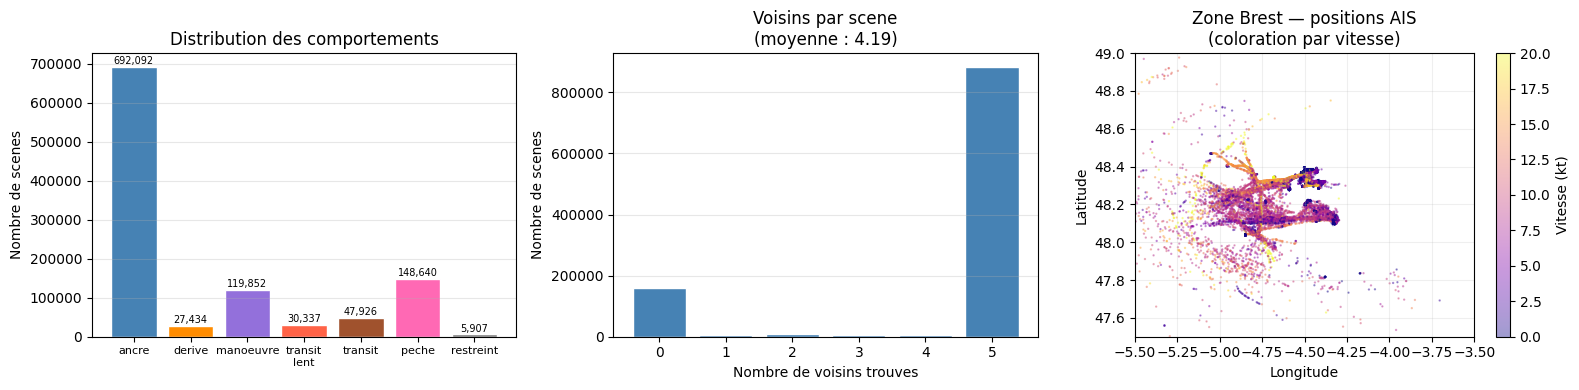

Sauvegarde : outputs/scene_overview.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# distribution comportements
beh_names_fr = ['ancre', 'derive', 'manoeuvre', 'transit\nlent',
                 'transit', 'peche', 'restreint']
beh_counts_plot = [meta_df['behavior'].value_counts().get(i, 0)
                   for i in range(7)]
colors = ['steelblue', 'darkorange', 'mediumpurple', 'tomato',
          'sienna', 'hotpink', 'gray']
axes[0].bar(beh_names_fr, beh_counts_plot, color=colors, edgecolor='white')
axes[0].set_title('Distribution des comportements')
axes[0].set_ylabel('Nombre de scenes')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(beh_counts_plot):
    axes[0].text(i, v + max(beh_counts_plot)*0.01, f'{v:,}',
                 ha='center', fontsize=7)

# distribution nombre de voisins
nb_counts = meta_df['n_neighbors'].value_counts().sort_index()
axes[1].bar(nb_counts.index, nb_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title(f'Voisins par scene\n(moyenne : {meta_df["n_neighbors"].mean():.2f})')
axes[1].set_xlabel('Nombre de voisins trouves')
axes[1].set_ylabel('Nombre de scenes')
axes[1].grid(axis='y', alpha=0.3)

# positions AIS sur la zone Brest
sample_map = ais.sample(min(30_000, len(ais)), random_state=42)
sc = axes[2].scatter(sample_map['lon'], sample_map['lat'],
                     c=sample_map['speed_kt'].clip(0, 20),
                     cmap='plasma', s=0.5, alpha=0.4, vmin=0, vmax=20)
plt.colorbar(sc, ax=axes[2], label='Vitesse (kt)')
axes[2].set_xlim(*BREST_LON)
axes[2].set_ylim(*BREST_LAT)
axes[2].set_title('Zone Brest — positions AIS\n(coloration par vitesse)')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].grid(alpha=0.2)

fig.tight_layout()
fig.savefig(OUT_DIR / 'scene_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : outputs/scene_overview.png')

## Apercu des scenes construites

Les scenes maritimes constituent le coeur du pipeline. Chaque scene est un instantane de 5 minutes
autour d'un navire, enrichi avec son contexte spatial (voisins proches) et environnemental
(meteo, ocean, geographie). Elle est representee par un vecteur de 49 dimensions decompose
en trois blocs.

### Structure d'une scene (49D)

**Bloc ego (13D)** — cinematique du navire sur la fenetre de contexte

| Feature | Description |
|---|---|
| mean_speed_kt | Vitesse moyenne sur la fenetre (noeuds) |
| std_speed_kt | Variabilite de la vitesse |
| mean_sin_cog | Cap moyen encode en sinus |
| mean_cos_cog | Cap moyen encode en cosinus |
| mean_turn_rate | Taux de virage moyen (deg/min) |
| total_distance_nm | Distance totale parcourue (nm) |
| acceleration | Variation de vitesse (kt/min) |
| beh_0 ... beh_5 | Comportement dominant encode en one-hot (6 classes) |

**Bloc environnemental (9D)** — contexte geographique et meteo

| Feature | Source |
|---|---|
| dist_coast_nm | Distance a la cote (shapefile European Coastline) |
| dist_port_nm | Distance au port le plus proche (Ports of Brittany) |
| in_tss | Dans un couloir de circulation (placeholder) |
| in_anchorage | Zone de mouillage (placeholder) |
| wind_kt | Vitesse du vent (stations meteo, conversion m/s -> kt) |
| wind_dir_sin | Direction du vent encodee en sinus |
| wind_dir_cos | Direction du vent encodee en cosinus |
| wave_height_m | Hauteur significative des vagues (WAVEWATCH III) |
| visibility_km | Visibilite meteorologique (km) |

**Bloc voisins (3 x 9D = 27D)** — les 3 navires les plus proches dans un rayon de 5 nm

| Feature | Description |
|---|---|
| present | 1 si le voisin existe, 0 sinon |
| bearing_sin / bearing_cos | Relèvement encode cycliquement |
| distance_nm | Distance haversine (nm) |
| rel_speed_kt | Vitesse de rapprochement (positif = s'approche) |
| course_diff_deg | Difference de cap entre ego et voisin [0-180 deg] |
| cpa_nm | Closest Point of Approach (nm) |
| tcpa_min | Time to CPA (min) |
| collision_risk | Score 0-1 = exp(-CPA/0.5) x exp(-TCPA/15) |

### Classification comportementale

Les comportements sont deduits automatiquement des donnees AIS brutes via des regles
heuristiques basees sur la vitesse, le taux de virage, le statut navigationnel AIS
et le type de navire. Ce ne sont pas des labels annotes manuellement.

| Code | Comportement | Criteres |
|---|---|---|
| 0 | Ancre / Amarre | speed < 0.5 kt ou nav_status = ancre/amarre |
| 1 | Derive | speed < 3 kt, peu de virages |
| 2 | Manoeuvre | turn_rate > 3 deg/min |
| 3 | Transit lent | 3 a 8 kt, cap stable |
| 4 | Transit | > 8 kt, cap stable |
| 5 | Peche / Chalutage | lent + virages + cote, ou nav_status = fishing, ou type = fishing |
| 6 | Restreint | nav_status = restricted / aground / not under command |

## 7. Normalisation et Dataset PyTorch

In [10]:
sequences_arr = np.array(sequences_16d, dtype='float32')  # (N, total_len, 16)

SEQ_MEAN = np.nanmean(sequences_arr, axis=(0, 1))
SEQ_STD  = np.nanstd(sequences_arr,  axis=(0, 1))
SEQ_STD  = np.where(SEQ_STD < 1e-8, 1.0, SEQ_STD)

np.save(OUT_DIR / 'seq_mean.npy', SEQ_MEAN)
np.save(OUT_DIR / 'seq_std.npy',  SEQ_STD)

sequences_norm = (sequences_arr - SEQ_MEAN) / SEQ_STD
sequences_norm = np.nan_to_num(sequences_norm, nan=0.0, posinf=0.0, neginf=0.0)
print(f'Shape sequences normalisees : {sequences_norm.shape}')


class MaritimeDataset(Dataset):
    def __init__(self, seqs, meta_list, mask_ratio=MASK_RATIO):
        self.seqs       = torch.tensor(seqs, dtype=torch.float32)
        self.meta       = meta_list
        self.mask_ratio = mask_ratio
        self.ctx        = CONTEXT_STEPS

    def __len__(self): return len(self.seqs)

    def __getitem__(self, idx):
        seq     = self.seqs[idx]
        context = seq[:self.ctx]         # (12, 16)
        target  = seq[self.ctx:]         # (30, 16)

        n_mask    = int(self.ctx * self.mask_ratio)
        mask_idx  = torch.randperm(self.ctx)[:n_mask]
        masked    = context.clone()
        masked[mask_idx] = 0.0
        mask      = torch.zeros(self.ctx, dtype=torch.bool)
        mask[mask_idx] = True

        # features d'aretes du voisin le plus proche (5D)
        edge_f = self.meta[idx].get('edge_feats', [])
        if edge_f:
            ef = torch.tensor(edge_f[0], dtype=torch.float32)
        else:
            ef = torch.zeros(5, dtype=torch.float32)

        return {
            'context':  masked,
            'original': context,
            'target':   target,
            'mask':     mask,
            'edge_feat': ef,
        }


# split 85/15
n = len(sequences_norm)
perm  = np.random.permutation(n)
n_val = int(n * 0.15)
idx_val, idx_train = perm[:n_val], perm[n_val:]

ds_train = MaritimeDataset(sequences_norm[idx_train], [seq_meta[i] for i in idx_train])
ds_val   = MaritimeDataset(sequences_norm[idx_val],   [seq_meta[i] for i in idx_val])

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train : {len(ds_train):,} | Val : {len(ds_val):,}')
print(f'Batches train : {len(dl_train)} | val : {len(dl_val)}')

Shape sequences normalisees : (1072188, 42, 16)
Train : 911,360 | Val : 160,828
Batches train : 56960 | val : 10052
